In [2]:
pip install yfinance pandas pytz 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import yfinance as yf

In [4]:
print("Data downloading...")
# soxl data download.
df = yf.download(tickers='SOXL',period='1mo',interval='5m')
# change timezone to Vancouver timezone.
df.index = df.index.tz_convert("America/Vancouver")

Data downloading...


[*********************100%***********************]  1 of 1 completed


In [5]:
df.head(10)

Price,Close,High,Low,Open,Volume
Ticker,SOXL,SOXL,SOXL,SOXL,SOXL
Datetime,,,,,
2026-08-25 06:30:00-07:00,119.810501,119.879997,116.010101,117.370003,10318001
2026-08-25 06:35:00-07:00,116.889999,119.839996,116.599998,119.839996,1431439
2026-08-25 06:40:00-07:00,117.529999,118.155899,116.720001,116.870003,891215
2026-08-25 06:45:00-07:00,118.635300,119.489899,116.879997,117.540001,1265120
2026-08-25 06:50:00-07:00,117.723198,119.145798,117.699997,118.675003,819424
2026-08-25 06:55:00-07:00,117.150002,117.799896,116.599998,117.709999,1053381
2026-08-25 07:00:00-07:00,115.690002,117.161003,115.200104,117.150002,1247072
2026-08-25 07:05:00-07:00,116.080002,116.650002,115.559998,115.720001,841529


In [6]:
df.target = df.between_time('06:30', '13:00')
df.target.head(10)

C:\Users\woobi\AppData\Local\Temp\ipykernel_1820\1343469788.py:1: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.target = df.between_time('06:30', '13:00')


Price,Close,High,Low,Open,Volume
Ticker,SOXL,SOXL,SOXL,SOXL,SOXL
Datetime,,,,,
2026-08-25 06:30:00-07:00,119.810501,119.879997,116.010101,117.370003,10318001
2026-08-25 06:35:00-07:00,116.889999,119.839996,116.599998,119.839996,1431439
2026-08-25 06:40:00-07:00,117.529999,118.155899,116.720001,116.870003,891215
2026-08-25 06:45:00-07:00,118.635300,119.489899,116.879997,117.540001,1265120
2026-08-25 06:50:00-07:00,117.723198,119.145798,117.699997,118.675003,819424
2026-08-25 06:55:00-07:00,117.150002,117.799896,116.599998,117.709999,1053381
2026-08-25 07:00:00-07:00,115.690002,117.161003,115.200104,117.150002,1247072
2026-08-25 07:05:00-07:00,116.080002,116.650002,115.559998,115.720001,841529


In [7]:
lowest_times = df.target.groupby(df.target.index.date)['Low'].idxmin()
lowest_times

Price,Low
Ticker,SOXL
2026-08-25,2026-08-25 07:30:00-07:00
2026-08-26,2026-08-26 07:25:00-07:00
2026-08-27,2026-08-27 06:55:00-07:00
2026-08-28,2026-08-28 10:05:00-07:00
2026-08-31,2026-08-31 09:05:00-07:00
2026-09-01,2026-09-01 06:40:00-07:00
2026-09-02,2026-09-02 06:55:00-07:00
2026-09-03,2026-09-03 06:35:00-07:00
2026-09-04,2026-09-04 06:30:00-07:00


In [8]:
highest_times = df.target.groupby(df.target.index.date)['High'].idxmax()
highest_times


Price,High
Ticker,SOXL
2026-08-25,2026-08-25 06:30:00-07:00
2026-08-26,2026-08-26 12:00:00-07:00
2026-08-27,2026-08-27 06:30:00-07:00
2026-08-28,2026-08-28 06:40:00-07:00
2026-08-31,2026-08-31 06:30:00-07:00
2026-09-01,2026-09-01 08:45:00-07:00
2026-09-02,2026-09-02 07:35:00-07:00
2026-09-03,2026-09-03 11:50:00-07:00
2026-09-04,2026-09-04 12:55:00-07:00


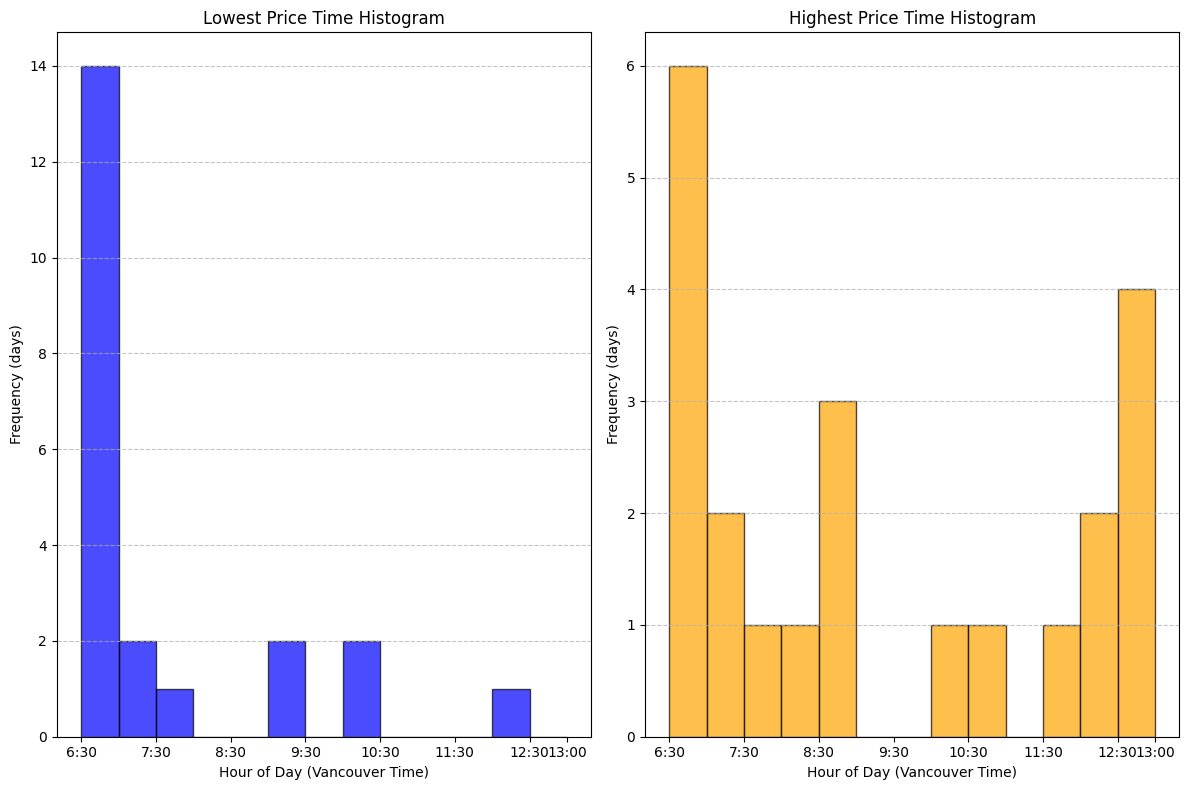

In [9]:
import matplotlib.pyplot as plt

low_series = lowest_times.iloc[:, 0]
high_series = highest_times.iloc[:, 0]

low_hours = low_series.dt.hour + low_series.dt.minute / 60
high_hours = high_series.dt.hour + high_series.dt.minute / 60

fig, axes = plt.subplots(1, 2, figsize=(12, 8))

axes[0].hist(low_hours,bins=13,range=(6.5,13),edgecolor='black',color='blue',alpha=0.7)
axes[0].set_title('Lowest Price Time Histogram')
axes[0].set_xlabel('Hour of Day (Vancouver Time)')
axes[0].set_ylabel('Frequency (days)') 
axes[0].set_xticks([6.5, 7.5, 8.5, 9.5, 10.5, 11.5, 12.5, 13.0])
axes[0].set_xticklabels(['6:30', '7:30', '8:30', '9:30', '10:30', '11:30', '12:30', '13:00'])
axes[0].grid(axis='y',linestyle='--',alpha=0.75)

axes[1].hist(high_hours,bins=13,range=(6.5,13),edgecolor='black',color='orange',alpha=0.7)
axes[1].set_title('Highest Price Time Histogram')       
axes[1].set_xlabel('Hour of Day (Vancouver Time)')
axes[1].set_ylabel('Frequency (days)')  
axes[1].set_xticks([6.5, 7.5, 8.5, 9.5, 10.5, 11.5, 12.5, 13.0])
axes[1].set_xticklabels(['6:30', '7:30', '8:30', '9:30', '10:30', '11:30', '12:30', '13:00'])
axes[1].grid(axis='y',linestyle='--',alpha=0.75)

plt.tight_layout()
plt.show()

In [10]:
df.head(3)

Price,Close,High,Low,Open,Volume
Ticker,SOXL,SOXL,SOXL,SOXL,SOXL
Datetime,,,,,
2026-08-25 06:30:00-07:00,119.810501,119.879997,116.010101,117.370003,10318001
2026-08-25 06:35:00-07:00,116.889999,119.839996,116.599998,119.839996,1431439
2026-08-25 06:40:00-07:00,117.529999,118.155899,116.720001,116.870003,891215


In [15]:
import pandas as pd

buy_trades = df.at_time('6:30')
sell_trades = df.at_time('12:55')

backtest_df = pd.DataFrame({
    'Buy_Price': buy_trades['Open'].iloc[:,0].values,
    'Sell_Price': sell_trades['Close'].iloc[:,0].values
},index=buy_trades.index.date)

backtest_df['Return_%'] = (backtest_df['Sell_Price'] - backtest_df['Buy_Price']) / backtest_df['Buy_Price'] * 100

backtest_df['Cumulative_Return_%'] = ((1 + backtest_df['Return_%'] / 100).cumprod() - 1)*100


backtest_df

,Buy_Price,Sell_Price,Return_%,Cumulative_Return_%
2026-08-25,117.370003,115.839996,-1.303575,-1.303575
2026-08-26,114.699997,116.665001,1.713168,0.387261
2026-08-27,123.400002,123.169998,-0.186388,0.200150
2026-08-28,119.919998,111.370003,-7.129749,-6.943869
2026-08-31,112.410004,112.845001,0.386974,-6.583766
2026-09-01,106.355003,105.779999,-0.540646,-7.088818
2026-09-02,104.500000,106.360001,1.779905,-5.435087
2026-09-03,103.000000,106.779999,3.669902,-1.964648
2026-09-04,111.220001,117.540001,5.682431,3.606143
2026-09-08,125.120003,123.349998,-1.414645,2.140484
